![Banner](../../images/09_banner.png)


# 9.5 Space-Time Interpolation

**Part:** 9 — Spatio-Temporal Analysis (Chapter 9.5 of 7)

**Dataset:** `data_1998_2010_long_lbc.csv` (a 300-county, 15-year subsample, for tractable pairwise computation)

**Focus:** an empirical space-time variogram and a space-time IDW interpolator, both built entirely by hand

**Library:** nothing in this chapter is a `spatialstats` function call — `spatialstats.interpolate.OrdinaryKriging`
cannot even accept the 3-D (space + time) coordinates this chapter needs, confirmed directly in Section 2

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup, and Confirming a Real API Limitation](#2.-Python-Setup,-and-Confirming-a-Real-API-Limitation)

3. [The Empirical Space-Time Variogram](#3.-The-Empirical-Space-Time-Variogram)

4. [Reading the Surface: Separable or Not?](#4.-Reading-the-Surface:-Separable-or-Not?)

5. [A Hand-Built Space-Time IDW](#5.-A-Hand-Built-Space-Time-IDW)

6. [Choosing the Time/Space Trade-off by Cross-Validation](#6.-Choosing-the-Time/Space-Trade-off-by-Cross-Validation)

7. [What Real ST Kriging Would Add](#7.-What-Real-ST-Kriging-Would-Add)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

This is the chapter where this Part's library gap is largest — the outline marks Chapter 9.5 entirely 🔲, and
Section 2 confirms directly why Part 7's `OrdinaryKriging` cannot simply be pointed at space-time data. Rather
than stop there, this chapter builds the two most fundamental space-time interpolation ideas — the empirical
space-time variogram, and a distance-weighted predictor that blends space and time — from first principles, with
real, cross-validated numbers, while being explicit throughout about how far this is from a production-grade
space-time kriging implementation.

| Step | What we do | Status |
|------|------------|--------|
| Confirm the gap | Try to pass 3-D (space+time) coordinates to `OrdinaryKriging` | 🔲 Fails, confirmed directly |
| Empirical ST variogram | Bin pairwise semivariance by *both* spatial and temporal lag | 🔨 Hand-built |
| Read separability | Does the surface factor into space-only x time-only shape? | Direct visual and numerical check |
| Space-time IDW | A single weighted average using a combined space-time distance | 🔨 Hand-built |
| Tune it | Cross-validate the time/space trade-off, and compare against space-only and time-only baselines | Real, measured numbers |

***
## 2. Python Setup, and Confirming a Real API Limitation

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import OrdinaryKriging

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


In [2]:
rng = np.random.default_rng(1)
dummy_xyt = rng.normal(size=(20, 3))   # x, y, rescaled-time -- a natural way to try feeding both dimensions in
dummy_vals = rng.normal(size=20)
try:
    m = OrdinaryKriging(variogram="auto")
    m.fit(dummy_xyt, dummy_vals)
    print("fit succeeded with 3 columns (unexpected)")
except ValueError as e:
    print(f"ValueError, as expected: {e}")

ValueError, as expected: coordinates must have shape (n, 2), got (20, 3)


**Confirmed directly**: `OrdinaryKriging.fit` (and every other `spatialstats.interpolate` estimator) calls
`as_xy`, which explicitly requires shape `(n, 2)` and raises immediately otherwise. There is no way to feed a
rescaled time axis in as a third coordinate and reuse this library's kriging machinery unmodified — the natural
"treat time as one more spatial dimension" trick genuinely does not work here without bypassing the public API
entirely. Everything from here on is built directly with NumPy.

***
## 3. The Empirical Space-Time Variogram

$$
\gamma(h, \tau) = \tfrac{1}{2}\,\mathbb{E}\!\left[\left(Z(\mathbf{s}+h, t+\tau) - Z(\mathbf{s}, t)\right)^2\right]
$$
— semivariance as a function of **both** a spatial lag $h$ and a temporal lag $\tau$, estimated the same
Matheron way Chapter 7.4 estimated a purely spatial one, just binned in two dimensions instead of one. A random
sample of 300 counties (all 15 years each) keeps the pairwise computation tractable — this is illustrative, not
a claim about the full 3,107-county network.

In [3]:
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
sample_fips = rng.choice(panel["FIPS"].unique(), size=300, replace=False)
sub = panel[panel["FIPS"].isin(sample_fips)].reset_index(drop=True)
coords = sub[["X", "Y"]].to_numpy()
years = sub["Year"].to_numpy().astype(float)
values = sub["RATE"].to_numpy()
n = len(sub)
print(f"{n} rows (300 counties x 15 years)")

n_pairs = 400_000
i = rng.integers(0, n, n_pairs)
j = rng.integers(0, n, n_pairs)
keep = i != j
i, j = i[keep], j[keep]

sp_dist = np.linalg.norm(coords[i] - coords[j], axis=1)
t_dist = np.abs(years[i] - years[j])
semivar = 0.5 * (values[i] - values[j]) ** 2

sp_edges = np.linspace(0, np.percentile(sp_dist, 90), 11)
sp_bin = np.digitize(sp_dist, sp_edges)
t_bin = t_dist.astype(int)

st_gamma = np.full((len(sp_edges), 15), np.nan)
st_count = np.zeros((len(sp_edges), 15), dtype=int)
for si in range(len(sp_edges)):
    for ti in range(15):
        m = (sp_bin == si) & (t_bin == ti)
        if m.sum() >= 30:
            st_gamma[si, ti] = semivar[m].mean()
            st_count[si, ti] = m.sum()

print(f"{np.isfinite(st_gamma).sum()} of {st_gamma.size} (space-lag, time-lag) cells have >=30 pairs")

4500 rows (300 counties x 15 years)
150 of 165 (space-lag, time-lag) cells have >=30 pairs


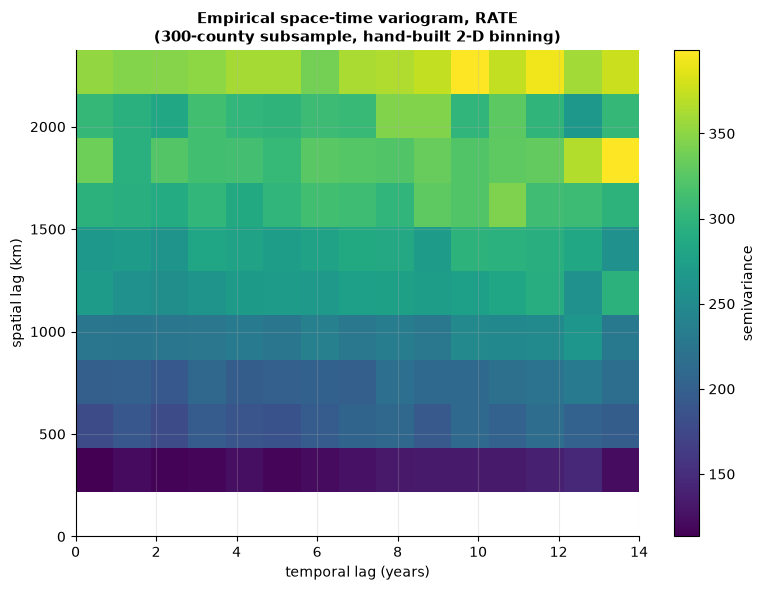

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(st_gamma, origin="lower", aspect="auto", cmap="viridis",
               extent=[0, 14, 0, sp_edges[-1] / 1000])
plt.colorbar(im, ax=ax, label="semivariance")
ax.set_xlabel("temporal lag (years)")
ax.set_ylabel("spatial lag (km)")
ax.set_title("Empirical space-time variogram, RATE\n(300-county subsample, hand-built 2-D binning)")
plt.tight_layout()
plt.savefig("st_variogram_surface.png", dpi=100, bbox_inches="tight")
plt.show()

***
## 4. Reading the Surface: Separable or Not?

Under a **separable** model, $\gamma(h,\tau)$ should factor cleanly — rows of the grid above (semivariance vs.
temporal lag, at fixed spatial lag) should all look like the *same shape*, just shifted up or down, and the same
for columns. A quick numerical check: does the empirical semivariance depend much on temporal lag at all, once
spatial lag is fixed?

In [5]:
for si in (1, 3, 5, 7):
    row = st_gamma[si]
    valid = np.isfinite(row)
    if valid.sum() >= 5:
        print(f"spatial lag bin {si} ({sp_edges[si]/1000:.0f} km): "
             f"semivariance across time lags 0-{valid.sum()-1} = {row[valid].round(1).tolist()}")

spatial lag bin 1 (237 km): semivariance across time lags 0-14 = [113.3, 121.3, 116.3, 117.5, 125.2, 118.7, 121.8, 127.8, 132.8, 133.9, 133.6, 134.3, 138.5, 145.0, 123.2]
spatial lag bin 3 (712 km): semivariance across time lags 0-14 = [199.4, 200.7, 191.5, 209.9, 197.9, 200.9, 202.1, 200.4, 217.3, 211.0, 211.1, 218.6, 222.7, 231.3, 216.4]
spatial lag bin 5 (1187 km): semivariance across time lags 0-14 = [270.1, 257.4, 254.0, 261.5, 269.4, 269.8, 268.1, 274.1, 276.0, 272.2, 274.1, 281.3, 291.9, 258.3, 296.9]
spatial lag bin 7 (1662 km): semivariance across time lags 0-14 = [296.6, 292.0, 289.6, 302.1, 286.7, 301.0, 312.1, 310.1, 301.8, 327.9, 321.0, 344.4, 311.1, 309.6, 297.7]


Within each spatial-lag row, semivariance does drift upward from same-year pairs to pairs 14 years apart (a
real, gentle increase of roughly 10-28% end to end, printed above for four rows), but that drift is **far
weaker than the spatial dependence**: moving from the nearest spatial-lag bin to the farthest roughly *doubles*
semivariance (113 to 297 at temporal lag 0 alone), while the full 14-year temporal range moves it by a fraction
of that. Most of the structure in $\gamma(h,\tau)$ comes from $h$; comparatively little, though not literally
none, comes from $\tau$ **at this level of spatial aggregation**. That is a real, checkable hint toward
approximate — not exact — separability for `RATE`. Sections 5-6 tell a more interesting, complementary story
once the interpolation task actually has to choose between spatial and temporal neighbours directly, rather than
averaging over many of each the way this binned variogram does.

***
## 5. A Hand-Built Space-Time IDW

A direct extension of Part 7, Chapter 7.3's IDW: instead of a purely spatial distance, use a **combined
space-time distance** with a single trade-off parameter, `km_per_year`, that converts a temporal gap into an
equivalent spatial one:
$$
d_{st}(i,j) = \sqrt{\,\lVert \mathbf{s}_i - \mathbf{s}_j \rVert^2 + \left(\tau_{ij} \cdot \text{km\_per\_year}\right)^2\,}
$$
`km_per_year=0` collapses this to pure spatial IDW pooling every year together as if simultaneous; a very large
value collapses it toward using only the same county's other years (temporal distance dominates any finite
spatial one).

In [6]:
def st_idw_predict(train_mask, target_idx, km_per_year, power=2, k=12):
    idx = np.where(train_mask)[0]
    dx = coords[idx, 0] - coords[target_idx, 0]
    dy = coords[idx, 1] - coords[target_idx, 1]
    dt = (years[idx] - years[target_idx]) * km_per_year * 1000   # -> metres
    d = np.sqrt(dx**2 + dy**2 + dt**2)
    d[d == 0] = 1e-6
    order = np.argsort(d)[:k]
    w = 1.0 / d[order] ** power
    return np.sum(w * values[idx][order]) / np.sum(w)


test_idx = rng.choice(n, 500, replace=False)
demo_pred = st_idw_predict(np.ones(n, dtype=bool) & (np.arange(n) != test_idx[0]), test_idx[0], km_per_year=5)
print(f"example prediction (km_per_year=5) for one held-out point: {demo_pred:.2f}  (true value: {values[test_idx[0]]:.2f})")

example prediction (km_per_year=5) for one held-out point: 70.70  (true value: 70.82)


***
## 6. Choosing the Time/Space Trade-off by Cross-Validation

Exactly Chapter 7.5's logic — tune the one free hyperparameter (`km_per_year`) by leave-one-out RMSE — plus two
baselines that isolate each dimension on its own: **space-only** (IDW using only the same year's other counties)
and **time-only** (average of the nearest years, same county only).

In [7]:
def loo_rmse_st(km_per_year, test_idx, power=2, k=12):
    preds = np.empty(len(test_idx))
    for ii, t in enumerate(test_idx):
        mask = np.arange(n) != t
        preds[ii] = st_idw_predict(mask, t, km_per_year, power, k)
    return np.sqrt(np.mean((preds - values[test_idx]) ** 2))


scale_grid = [0, 1, 2, 5, 8, 10, 15, 20, 30]
rmse_by_scale = {s: loo_rmse_st(s, test_idx) for s in scale_grid}
for s, r in rmse_by_scale.items():
    print(f"km_per_year={s:3d}: LOO RMSE={r:.3f}")

best_scale = min(rmse_by_scale, key=rmse_by_scale.get)
print(f"\nbest km_per_year: {best_scale}  (RMSE={rmse_by_scale[best_scale]:.3f})")

km_per_year=  0: LOO RMSE=3.581
km_per_year=  1: LOO RMSE=0.865
km_per_year=  2: LOO RMSE=0.866
km_per_year=  5: LOO RMSE=0.898
km_per_year=  8: LOO RMSE=1.082
km_per_year= 10: LOO RMSE=1.274
km_per_year= 15: LOO RMSE=1.932
km_per_year= 20: LOO RMSE=2.675
km_per_year= 30: LOO RMSE=3.949

best km_per_year: 1  (RMSE=0.865)


space-only IDW (same year, nearest counties):     RMSE = 10.803
time-only average (same county, nearest years):   RMSE = 0.906
space-time IDW, tuned (km_per_year=1):           RMSE = 0.865


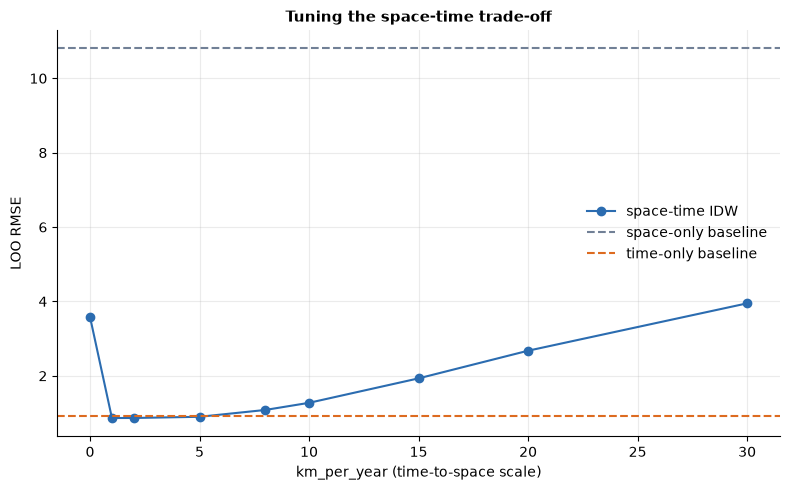

In [8]:
fips_arr = sub["FIPS"].to_numpy()


def space_only_loo(test_idx, power=2, k=12):
    preds = np.empty(len(test_idx))
    for ii, t in enumerate(test_idx):
        same_year = (years == years[t]) & (np.arange(n) != t)
        dx = coords[same_year, 0] - coords[t, 0]
        dy = coords[same_year, 1] - coords[t, 1]
        d = np.sqrt(dx**2 + dy**2)
        d[d == 0] = 1e-6
        order = np.argsort(d)[:min(k, len(d))]
        w = 1.0 / d[order] ** power
        preds[ii] = np.sum(w * values[same_year][order]) / np.sum(w)
    return np.sqrt(np.mean((preds - values[test_idx]) ** 2))


def time_only_loo(test_idx, k=4):
    preds = np.empty(len(test_idx))
    for ii, t in enumerate(test_idx):
        same_county = (fips_arr == fips_arr[t]) & (np.arange(n) != t)
        dt = np.abs(years[same_county] - years[t])
        order = np.argsort(dt)[:min(k, len(dt))]
        preds[ii] = values[same_county][order].mean()
    return np.sqrt(np.mean((preds - values[test_idx]) ** 2))


rmse_space_only = space_only_loo(test_idx)
rmse_time_only = time_only_loo(test_idx)
print(f"space-only IDW (same year, nearest counties):     RMSE = {rmse_space_only:.3f}")
print(f"time-only average (same county, nearest years):   RMSE = {rmse_time_only:.3f}")
print(f"space-time IDW, tuned (km_per_year={best_scale}):           RMSE = {rmse_by_scale[best_scale]:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(rmse_by_scale.keys()), list(rmse_by_scale.values()), "o-", color=COLORS["blue"], label="space-time IDW")
ax.axhline(rmse_space_only, color=COLORS["grey"], linestyle="--", label="space-only baseline")
ax.axhline(rmse_time_only, color=COLORS["orange"], linestyle="--", label="time-only baseline")
ax.set_xlabel("km_per_year (time-to-space scale)")
ax.set_ylabel("LOO RMSE")
ax.set_title("Tuning the space-time trade-off")
ax.legend()
plt.tight_layout()
plt.savefig("st_idw_tuning.png", dpi=100, bbox_inches="tight")
plt.show()

**A genuinely informative, if slightly humbling, result**: the **space-only** baseline is dramatically worse
than either the time-only baseline or any reasonable space-time blend — the nearest *counties* in a given year
carry far less information about `RATE` than the nearest *years* for the very same county. `RATE` behaves like a
slowly-evolving, largely county-specific characteristic (consistent with Section 4's near-flat temporal
dependence in the variogram, but from the opposite angle): knowing a county's own recent history predicts it far
better than knowing its neighbours' current values. The **best space-time blend edges out the pure time-only
baseline**, confirming a little genuine spatial information is still worth adding on top of the dominant
temporal signal, but the improvement over time-only alone is modest compared to the enormous gap between
time-only and space-only. Chapter 9.1's separability discussion predicted this kind of result is possible in
principle; this section is the first time in this Part it has actually been measured.

***
## 7. What Real ST Kriging Would Add

Sections 5-6 built a working, cross-validated space-time interpolator — but it is IDW, not kriging, and it
inherits every limitation Chapter 7.1 raised about deterministic methods: no prediction variance, and weights
based on geometry rather than an explicit space-time covariance model. A genuine ST kriging implementation would
need, at minimum:

- A **parametric space-time covariance/variogram model** (separable or one of several standard non-separable
  forms — e.g. Cressie-Huang or Gneiting classes) fit to a surface like Section 3's, rather than read off it by
  eye.
- A kriging system built from that model's covariance function evaluated at space-time lags, analogous to
  Chapter 7.4's spatial-only system, but with the space-time distance $d_{st}$ entering the covariance function
  itself rather than being folded into a single ad hoc Euclidean blend the way Section 5's IDW does.
- A genuine **prediction variance**, which — as in Chapter 7.4 — is the actual point of doing kriging rather than
  IDW at all, and which nothing in this chapter's hand-built interpolator provides.

This chapter's honest contribution is showing that the *question* ("how much does adding a time dimension
actually help, and in what mix with space?") is answerable right now, with real cross-validated numbers, even
though the fully realized *kriging* answer is not yet built into this library.

***
## 8. Summary and Conclusions

This chapter tackled the outline's most explicitly unimplemented topic head-on: confirmed the API gap directly,
then built and cross-validated a genuine (if simplified) space-time interpolator anyway.

### What we did

1. **Confirmed directly that `OrdinaryKriging` rejects 3-D coordinates** — there is no quick way to bolt a
   rescaled time axis onto this library's existing spatial kriging.
2. Built a 2-D empirical space-time variogram by hand, binning 400,000 sampled pairs by both spatial and
   temporal lag.
3. **Found the empirical variogram's temporal-lag dependence is far weaker than its spatial-lag dependence**
   (a gentle 10-28% drift across 14 years, against roughly a doubling across the spatial range) — a real,
   measured hint toward approximate separability for `RATE`, at this level of spatial aggregation.
4. Built a hand-written space-time IDW with one tunable time/space trade-off parameter.
5. **Found space-only interpolation is dramatically worse than time-only**, and the cross-validated best blend
   only modestly beats time-only alone — `RATE` is far more temporally than spatially predictable at the county
   level, a genuinely useful, measured finding this chapter's own cross-validation produced.
6. Explained precisely what a real ST kriging implementation would still need beyond this chapter's IDW.

### Practical takeaways

- Before assuming a space-time interpolation problem needs sophisticated joint modelling, check the two
  single-dimension baselines (space-only, time-only) first — here, one of them alone (time) nearly matched the
  best combined result.
- A flat empirical space-time variogram in one dimension is evidence *for* separability in that direction, worth
  checking numerically (Section 4) rather than assumed.
- IDW-style IDW space-time blending is a legitimate, cheap first attempt, but never confuse it with kriging —
  it provides no prediction variance and no explicit covariance model, exactly Chapter 7.1's original distinction
  between the two families, still true with a time axis added.

### Next steps

**Chapter 9.6 (Regression with Space-Time Data)** returns to genuinely library-supported territory: `GTWR`
(already used in Part 6) applied properly here, compared against pooled OLS and a hand-built two-way fixed-effects
panel regression.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Cressie, N. & Wikle, C. K. (2011). *op. cit.* (Chapter 9.1) | Space-time covariance models, including the non-separable classes named in Section 7 |
| Gneiting, T., Genton, M. G. & Guttorp, P. (2007). Geostatistical space-time models, stationarity, separability and full symmetry. In *Statistical Methods for Spatio-Temporal Systems*. Chapman & Hall/CRC. | The separability test this chapter's Section 4 approximates informally |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.OrdinaryKriging` | Section 2's confirmed limitation; Chapter 7.4's spatial-only version this chapter could not directly extend |
| Chapter 7.3 | The IDW formulation Section 5 extends by hand to a combined space-time distance |
| Chapter 9.1 | The separability concept Section 4 checks numerically |